# QUEST 3
__Bar charts__

In [4]:
import pandas as pd
import sqlite3

database_path = "../data/checking-logs.sqlite"

In [5]:
try:
    connection = sqlite3.connect(database_path)
except Exception:
    print("Не удалось подключиться к СУБД :(")

for each hour, calculate the average number of commits on working days and on weekends (if there were no commits in an hour, do not use it to calculate the average) use these values for your graph, for example: Mon, 17-18: 5 commits, Tue, 17-18: 6 commits, Wed, 17-18: 7 commits

In [6]:
query = """
select timestamp from checker
where uid like 'user_%'
"""
df = pd.io.sql.read_sql(query, connection, parse_dates="timestamp")


In [7]:
display(df)

,timestamp
0,2020-04-17 05:19:02.744528
1,2020-04-17 05:22:35.249331
2,2020-04-17 05:22:45.549397
3,2020-04-17 05:34:14.691200
4,2020-04-17 05:34:24.422370
...,...
3202,2020-05-21 20:19:06.872761
3203,2020-05-21 20:22:41.785725
3204,2020-05-21 20:22:41.877806
3205,2020-05-21 20:37:00.129678


In [8]:
#df["hour"] = pd.cut(df["timestamp"].dt.hour, bins=list(range(0, 25)), right=False, labels=list(range(0, 24)))
df["hour"] = df["timestamp"].dt.hour
df["weekday"] = df["timestamp"].dt.dayofweek.apply(lambda x: "working day" if x < 5 else "weekend")
df["timestamp"] = df["timestamp"].dt.date
df["av commit"] = df["hour"]
display(df)

,timestamp,hour,weekday,av commit
0,2020-04-17,5,working day,5
1,2020-04-17,5,working day,5
2,2020-04-17,5,working day,5
3,2020-04-17,5,working day,5
4,2020-04-17,5,working day,5
...,...,...,...,...
3202,2020-05-21,20,working day,20
3203,2020-05-21,20,working day,20
3204,2020-05-21,20,working day,20
3205,2020-05-21,20,working day,20


In [9]:
g = df.groupby(["weekday", "timestamp", "hour"]).count()
display(g)

av commit
weekday     timestamp  hour           
weekend     2020-04-18 7             1
                       13            5
                       14            3
                       15           25
                       17            7
...                                ...
working day 2020-05-21 16            4
                       17            1
                       18            2
                       19            8
                       20           10

[288 rows x 1 columns]

In [10]:

df = g.groupby(["weekday", "hour"])["av commit"].mean().reset_index()
display(df.head(40))

,weekday,hour,av commit
0,weekend,0,2.000000
1,weekend,1,6.000000
2,weekend,3,1.000000
3,weekend,5,2.000000
4,weekend,7,4.000000
5,weekend,8,7.000000
6,weekend,9,3.666667
7,weekend,10,7.000000
8,weekend,11,23.600000
9,weekend,12,9.500000


In [11]:
df_new = pd.pivot_table(g, index = "hour", columns="weekday", values="av commit")
display(df_new)

weekday,weekend,working day
hour,,
0,2.000000,3.000000
1,6.000000,NaN
3,1.000000,2.000000
5,2.000000,7.500000
6,NaN,1.500000
7,4.000000,5.166667
8,7.000000,3.700000
9,3.666667,6.000000
10,7.000000,13.200000


In [ ]:
print(df_new.count())

## Plotting

array([<AxesSubplot:title={'center':'weekend'}, xlabel='hour'>,
       <AxesSubplot:title={'center':'working day'}, xlabel='hour'>],
      dtype=object)

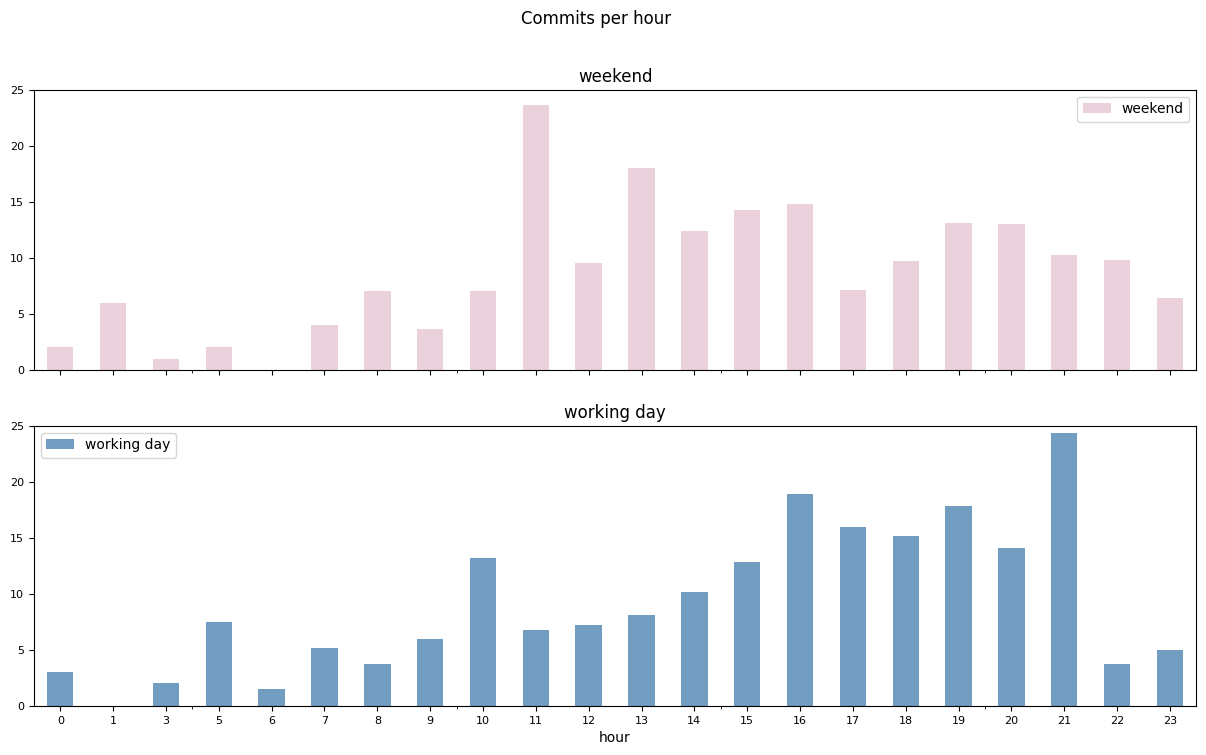

In [12]:
df_new.plot(kind = "bar", title="Commits per hour", subplots=True, rot=0, figsize=(15, 8), fontsize=8, color=["#ead1dc", "#729cc0"],
            ylim=[0,25])

## Is the dynamic different on working days and weekends? - __YES__

* for the answer include the hour when the number of commits is the largest during working days and the hour when it is the largest during the weekend.

The largest hour during working dates (9 pm):

In [13]:
df_new[df_new["working day"] == df_new["working day"].max()]

weekday,weekend,working day
hour,,
21,10.285714,24.333333


The largest hour during holidays (11 am):

In [14]:
df_new[df_new["weekend"] == df_new["weekend"].max()]

weekday,weekend,working day
hour,,
11,23.6,6.769231


In [15]:
connection.close()